In [1]:
import torch
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score
from core import *
from utils import *
from lark import Tree, Token
from pm4py import save_vis_petri_net
import random
import pandas as pd
import sys
from sklearn import tree as sktree
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.cluster import DBSCAN

from utils import get_decoding

#print(f"Versione Python: {sys.version}")

#print(torch.cuda.is_available())
#print(torch.__version__)

# SETTINGS
NARY = 1
PROBABILITIES = 0.2,0.2,0.2,0.4
FILE_PATH_PNG = "petri_net_output.png"
TRACE_ENC_REG = "data/regions_full.csv"
TRACE_ENC_TAS = "data/tasks_full.csv"
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)
learning_rate = 3e-4

cuda


In [2]:
iterations = 15  # Quante iterazioni diverse (numero regioni prima di minimizzare in teoria)
current_string = SEED_STRING
for _ in range(iterations):
    current_string = replace_random_underscore(current_string, PROBABILITIES)

process = replace_underscores(current_string)
tree = PARSER.parse(process)

# ALBERI GIOCATTOLO

#1 LOOP
'''tree = Tree('xor', [
    Tree('sequential', [
        Tree('loop', [
            Tree('task', [Token('NAME', 'T1')])
        ]),
        Tree('xor', [
            Tree('task', [Token('NAME', 'T2')]),
            Tree('task', [Token('NAME', 'T3')])
        ])
    ]),
    Tree('parallel', [
        Tree('task', [Token('NAME', 'T4')]),
        Tree('task', [Token('NAME', 'T5')])
    ])
])'''

#2 LOOP
tree = Tree('xor', [
    Tree('sequential', [
        Tree('loop', [
            Tree('task', [Token('NAME', 'T1')])
        ]),
        Tree('xor', [
            Tree('task', [Token('NAME', 'T2')]),
            Tree('task', [Token('NAME', 'T3')])
        ])
    ]),
    Tree('parallel', [
        Tree('loop', [   # loop inserito in un ramo del parallel
            Tree('task', [Token('NAME', 'T4')])
        ]),
        Tree('task', [Token('NAME', 'T5')])
    ])
])

#tree = Tree('xor', [Tree('loop', [Tree('sequential', [Tree('loop', [Tree('task', [Token('NAME', 'T1')])]), Tree('xor', [Tree('task', [Token('NAME', 'T2')]), Tree('task', [Token('NAME', 'T3')])])])]), Tree('parallel', [Tree('task', [Token('NAME', 'T4')]), Tree('loop', [Tree('task', [Token('NAME', 'T5')])])])])

#tree = Tree('xor', [Tree('task', [Token('NAME', 'T1')]),Tree('sequential', [Tree('parallel', [Tree('xor', [Tree('task', [Token('NAME', 'T2')]),Tree('xor', [Tree('task', [Token('NAME', 'T3')]),Tree('task', [Token('NAME', 'T4')])])]),Tree('parallel', [Tree('task', [Token('NAME', 'T5')]),Tree('task', [Token('NAME', 'T6')])])]),Tree('sequential', [Tree('task', [Token('NAME', 'T7')]),Tree('task', [Token('NAME', 'T8')])])])])

#tree = Tree('xor', [Tree('loop', [Tree('sequential', [Tree('loop', [Tree('task', [Token('NAME', 'T1')])]), Tree('xor', [Tree('task', [Token('NAME', 'T2')]), Tree('task', [Token('NAME', 'T3')])])])]), Tree('parallel', [Tree('task', [Token('NAME', 'T4')]), Tree('loop', [Tree('task', [Token('NAME', 'T5')])])])])

if NARY: # Se true allora faccio l'albero ennario (semplifico)
    tree = createNAryTree(tree)

#tree = Tree('loop', [Tree('parallel', [Tree('sequential', [Tree('loop', [Tree('parallel', [Tree('task', [Token('NAME', 'T1')]), Tree('task', [Token('NAME', 'T2')])])]), Tree('loop', [Tree('parallel', [Tree('loop', [Tree('task', [Token('NAME', 'T3')])]), Tree('task', [Token('NAME', 'T4')])])])]), Tree('loop', [Tree('sequential', [Tree('task', [Token('NAME', 'T5')]), Tree('loop', [Tree('task', [Token('NAME', 'T6')])])])])])])

print(tree)

Tree('xor', [Tree('sequential', [Tree('loop', [Tree('task', [Token('NAME', 'T1')])]), Tree('xor', [Tree('task', [Token('NAME', 'T2')]), Tree('task', [Token('NAME', 'T3')])])]), Tree('parallel', [Tree('loop', [Tree('task', [Token('NAME', 'T4')])]), Tree('task', [Token('NAME', 'T5')])])])


In [3]:
net = PetriNetP(tree)

save_vis_petri_net(
    net.net,
    net.initial_marking,
    net.final_marking,
    FILE_PATH_PNG,
    format="png"
)

# Oggetto Generator
generator = Generator(5000, net)
generator.generateTrace(False) # with False we don't clean the trace

[['start_X0',
  'start_L2',
  'start_T1',
  'end_T1',
  'back_L2',
  'start_T1',
  'end_T1',
  'end_L2',
  'start_X3',
  'start_T2',
  'end_T2',
  'end_X3',
  'end_X0'],
 ['start_X0',
  'start_L2',
  'start_T1',
  'end_T1',
  'end_L2',
  'start_X3',
  'start_T2',
  'end_T2',
  'end_X3',
  'end_X0'],
 ['start_X0',
  'start_L2',
  'start_T1',
  'end_T1',
  'back_L2',
  'start_T1',
  'end_T1',
  'end_L2',
  'start_X3',
  'start_T3',
  'end_T3',
  'end_X3',
  'end_X0'],
 ['start_X0',
  'start_P4',
  'start_L5',
  'start_T5',
  'end_T5',
  'start_T4',
  'end_T4',
  'back_L5',
  'start_T4',
  'end_T4',
  'end_L5',
  'end_P4',
  'end_X0'],
 ['start_X0',
  'start_L2',
  'start_T1',
  'end_T1',
  'back_L2',
  'start_T1',
  'end_T1',
  'end_L2',
  'start_X3',
  'start_T3',
  'end_T3',
  'end_X3',
  'end_X0'],
 ['start_X0',
  'start_L2',
  'start_T1',
  'end_T1',
  'back_L2',
  'start_T1',
  'end_T1',
  'end_L2',
  'start_X3',
  'start_T3',
  'end_T3',
  'end_X3',
  'end_X0'],
 ['start_X0',
  'st

In [4]:
# Creazione dei decision tree per 'limitare' i loop e provare a dargli un 'senso'
classifier_dict_loop = {}

for loop in net.loop_regions:
    result = create_loop_data(loop, generator.generatedTraces)
    if result is None:
        continue

    x, y, dict_loop_step_encoding, max_len = result

    decisiontree = sktree.DecisionTreeClassifier(max_depth=5, class_weight='balanced') #Se mettiamo class_weight='balanced' è come se avessimo pompato le tracce
    decisiontree = decisiontree.fit(x, y)

    print(loop)
    classifier_dict_loop[loop] = (decisiontree, dict_loop_step_encoding, max_len)

print(classifier_dict_loop)

L2
L5
{'L2': (DecisionTreeClassifier(class_weight='balanced', max_depth=5), {'end_T1': 0, 'start_L2': 1, 'back_L2': 2, 'PAD': 3, 'start_X0': 4, 'start_T1': 5}, 37), 'L5': (DecisionTreeClassifier(class_weight='balanced', max_depth=5), {'start_T5': 0, 'start_T4': 1, 'start_L5': 2, 'back_L5': 3, 'start_P4': 4, 'PAD': 5, 'end_T5': 6, 'end_T4': 7, 'start_X0': 8}, 40)}


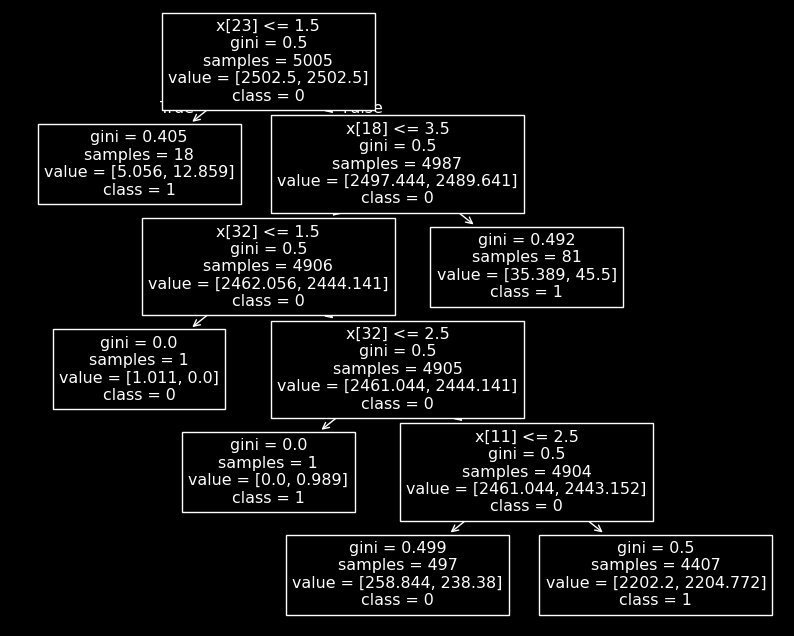

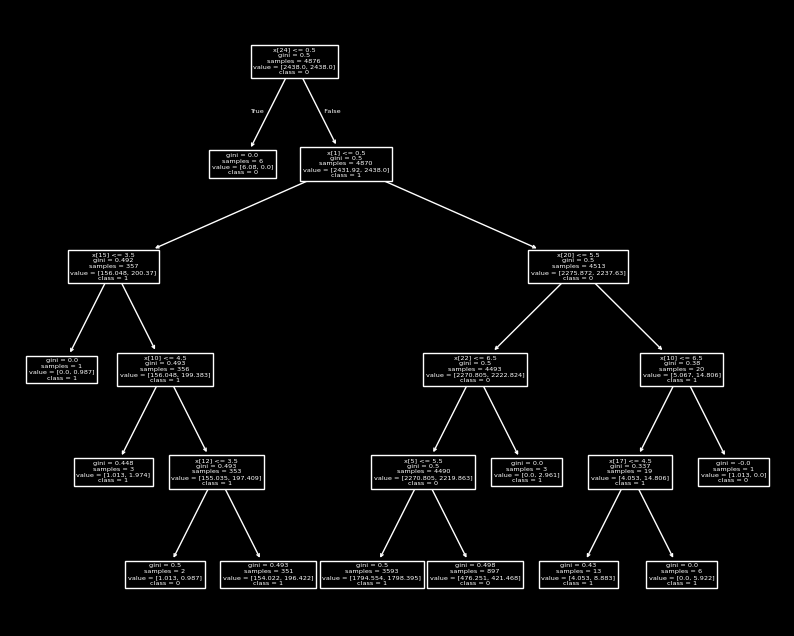

In [5]:
for clf,_,_ in classifier_dict_loop.values():
    plt.figure(figsize=(10, 8))
    sktree.plot_tree(clf,
               class_names=["0", "1"])
    plt.show()

In [6]:
# Rigenero le tracce utilizzando i classificatori
generator.generateTraceCond(classifier_dict_loop)

[['start_T1', 'end_T1', 'end_L2', 'start_T2', 'end_T2'],
 ['start_T1', 'end_T1', 'end_L2', 'start_T3', 'end_T3'],
 ['start_T5', 'end_T5', 'start_T4', 'end_T4', 'end_L5'],
 ['start_T4', 'end_T4', 'end_L5', 'start_T5', 'end_T5'],
 ['start_T1', 'end_T1', 'end_L2', 'start_T3', 'end_T3'],
 ['start_T1', 'end_T1', 'end_L2', 'start_T2', 'end_T2'],
 ['start_T4', 'start_T5', 'end_T4', 'end_L5', 'end_T5'],
 ['start_T1', 'end_T1', 'end_L2', 'start_T2', 'end_T2'],
 ['start_T1', 'end_T1', 'end_L2', 'start_T3', 'end_T3'],
 ['start_T1', 'end_T1', 'end_L2', 'start_T3', 'end_T3'],
 ['start_T5', 'start_T4', 'end_T5', 'end_T4', 'end_L5'],
 ['start_T5', 'end_T5', 'start_T4', 'end_T4', 'end_L5'],
 ['start_T1', 'end_T1', 'end_L2', 'start_T3', 'end_T3'],
 ['start_T5', 'end_T5', 'start_T4', 'end_T4', 'end_L5'],
 ['start_T4', 'end_T4', 'end_L5', 'start_T5', 'end_T5'],
 ['start_T1', 'end_T1', 'end_L2', 'start_T2', 'end_T2'],
 ['start_T5', 'end_T5', 'start_T4', 'end_T4', 'end_L5'],
 ['start_T5', 'start_T4', 'end_

In [7]:
# Creazione matrice identità delle regioni
df_region_identity = pd.DataFrame.from_dict(net.node_identity, orient='index').sort_index()
df_region_identity.columns = ['X', '+', '->', '<>']
print(df_region_identity)

# Creazione matrice regioni-figli per le regioni
df_region_children = pd.Series(net.node_children).explode()
df_region_children = pd.crosstab(df_region_children.index, df_region_children)
df_region_children = df_region_children.reindex(index=net.regions, columns=net.regions + net.tasks, fill_value=0)
df_region_children = df_region_children.astype(int)
df_region_children.index.name = None
df_region_children.columns.name = None
print(df_region_children)

# Codifica delle tracce generate
traceEncoded_regions, traceEncoded_tasks = get_encoding(generator.generatedTraces, net.regions, net.tasks, net.open_clauses, net.end_clauses)

# Trovo numero regioni e numero task effettivo (torneranno utili in futuro)
num_regions = len([i for i in traceEncoded_regions.index if str(i).startswith('R')])
num_tasks = len([i for i in traceEncoded_tasks.index if str(i).startswith('T')])

# Creo il dataframe unico (regioni + task)
df_traces_complete = pd.concat([traceEncoded_regions, traceEncoded_tasks], axis=0)
print(df_traces_complete)

    X  +  ->  <>
R0  1  0   0   0
R1  0  0   1   0
R2  0  0   0   1
R3  1  0   0   0
R4  0  1   0   0
R5  0  0   0   1
    R0  R1  R2  R3  R4  R5  T1  T2  T3  T4  T5
R0   0   1   0   0   1   0   0   0   0   0   0
R1   0   0   1   1   0   0   0   0   0   0   0
R2   0   0   0   0   0   0   1   0   0   0   0
R3   0   0   0   0   0   0   0   1   1   0   0
R4   0   0   0   0   0   1   0   0   0   0   1
R5   0   0   0   0   0   0   0   0   0   1   0
    0      1      2      3      4      5      6      7      8      9      ...  \
R0      1      1      1      0      1      1      1      0      1      1  ...   
R1      1      1      1      0      1      1      1      0      0      0  ...   
R2      1      0      0      0      1      0      0      0      0      0  ...   
R3      0      0      1      0      0      0      1      0      0      0  ...   
R4      0      0      0      0      0      0      0      0      1      1  ...   
R5      0      0      0      0      0      0      0      0      0 

In [8]:
# Prendo tutte le tracce, le conto e poi creo una matrice di distanza tra tutte le possibili tracce --> mi servirà per la creazione dei cluster
all_traces = getall_traces(num_regions + num_tasks, df_traces_complete) # Ritorno la lista di tutte le tracce

trace_counts = Counter(all_traces)
traces_encoded = list(trace_counts.keys())
trace_weights = list(trace_counts.values())
n_traces = len(traces_encoded)

distance_matrix = create_distance_matrix(n_traces, traces_encoded, num_regions + num_tasks) # Creo la matrice di distanza utilizzando la weighted levenshtein (con hamming_distance)


In [9]:
# Clusterizzo
dbscan = DBSCAN(eps=6, min_samples=1, metric="precomputed")
dbscan.fit(distance_matrix, sample_weight=trace_weights)
cluster_labels = dbscan.labels_

df_clusters = pd.DataFrame({
    'Trace_Type': [str(t) for t in traces_encoded],
    'Frequency': trace_weights,
    'N_Cluster': cluster_labels
})
df_clusters = df_clusters.sort_values(by=['N_Cluster', 'Frequency'], ascending=[True, False])

# Visualizzo raggruppando dataframe per Cluster --> SOLO a scopo di visualizzazione
'''
for cluster_id, group in df_clusters.groupby('N_Cluster'):
    num_tracce_cluster = group['Frequency'].sum()
    varianti_per_cluster = len(group)

    print(f"\nCluster {cluster_id}")
    print(f"   ↳ {varianti_per_cluster} varianti uniche -> Rappresentano {num_tracce_cluster} tracce totali")

    varianti = group.head()
    for index, row in varianti.iterrows():
        traccia_str = row['Trace_Type']

        if len(traccia_str) > 80:
            traccia_str = traccia_str[:77] + "..."

        print(f"Freq: {row['Frequency']:<5} | Traccia: {traccia_str}")
'''


'\nfor cluster_id, group in df_clusters.groupby(\'N_Cluster\'):\n    num_tracce_cluster = group[\'Frequency\'].sum()\n    varianti_per_cluster = len(group)\n\n    print(f"\nCluster {cluster_id}")\n    print(f"   ↳ {varianti_per_cluster} varianti uniche -> Rappresentano {num_tracce_cluster} tracce totali")\n\n    varianti = group.head()\n    for index, row in varianti.iterrows():\n        traccia_str = row[\'Trace_Type\']\n\n        if len(traccia_str) > 80:\n            traccia_str = traccia_str[:77] + "..."\n\n        print(f"Freq: {row[\'Frequency\']:<5} | Traccia: {traccia_str}")\n'

In [10]:
# Prendo tot tracce per cluster --> per bilanciare le tracce generate e per non avere prevalentemente tracce dello stesso cluster
num_trace_per_cluster = 1000
balanced_traces, balanced_columns = get_balance_traces_by_cluster(traces_encoded, cluster_labels, num_trace_per_cluster)

df_traces_balanced = pd.DataFrame(balanced_columns).T  # Trasposta
df_traces_balanced.index = df_traces_complete.index
print(df_traces_balanced)

    0      1      2      3      4      5      6      7      8      9      ...  \
R0      1      1      1      0      1      1      1      0      1      1  ...   
R1      1      1      1      0      1      1      1      0      1      1  ...   
R2      1      0      0      0      1      0      0      0      1      0  ...   
R3      0      0      1      0      0      0      1      0      0      0  ...   
R4      0      0      0      0      0      0      0      0      0      0  ...   
R5      0      0      0      0      0      0      0      0      0      0  ...   
T1      1      0      0      0      1      0      0      0      1      0  ...   
T2      0      0      0      0      0      0      0      0      0      0  ...   
T3      0      0      1      0      0      0      1      0      0      0  ...   
T4      0      0      0      0      0      0      0      0      0      0  ...   
T5      0      0      0      0      0      0      0      0      0      0  ...   

    13990  13991  13992  13

In [11]:
# Operazioni per creazione funzione di codifica e decodifica da colonna ad id e viceversa (per REGIONE + TASK)
df_regions = df_traces_balanced.head(num_regions).copy()
df_tasks = df_traces_balanced.tail(num_tasks).copy()

df_traces_balanced = df_traces_balanced.T
df_traces_balanced = df_traces_balanced.copy()

unique_columns_complete = df_traces_balanced.drop_duplicates()
unique_tuple_complete = [tuple(x) for x in unique_columns_complete.values]

bit_to_id_traces_complete = {v: i for i, v in enumerate(unique_tuple_complete)}
id_to_bit_traces_complete = {i: v for i, v in enumerate(unique_tuple_complete)}

vocab_size_complete = len(unique_columns_complete)

encode_complete = lambda a: [bit_to_id_traces_complete[tuple(x)] for x in a]
decode_complete = lambda b: [id_to_bit_traces_complete[x] for x in b]

# Operazioni per creazione funzione di codifica e decodifica da colonna ad id e viceversa (solo per REGIONE)
df_regions = df_regions.T

unique_columns_regions = df_regions.drop_duplicates()
unique_tuple_regions = [tuple(x) for x in unique_columns_regions.values]

bit_to_id_traces_regions = {v: i for i, v in enumerate(unique_tuple_regions)}
id_to_bit_traces_regions = {i: v for i, v in enumerate(unique_tuple_regions)}

vocab_size_regions = len(unique_columns_regions)

encode_regions = lambda a: [bit_to_id_traces_regions[tuple(x)] for x in a]
decode_regions = lambda b: [id_to_bit_traces_regions[x] for x in b]

# Operazioni per creazione funzione di codifica e decodifica da colonna ad id e viceversa (solo per TASK)
df_tasks = df_tasks.T

unique_columns_tasks = df_tasks.drop_duplicates()
unique_tuple_tasks = [tuple(x) for x in unique_columns_tasks.values]

bit_to_id_traces_tasks = {v: i for i, v in enumerate(unique_tuple_tasks)}
id_to_bit_traces_tasks = {i: v for i, v in enumerate(unique_tuple_tasks)}

vocab_size_tasks = len(unique_columns_tasks)

encode_tasks = lambda a: [bit_to_id_traces_tasks[tuple(x)] for x in a]
decode_tasks = lambda b: [id_to_bit_traces_tasks[x] for x in b]

In [12]:
# Decodifico le tracce bilanciate con la funzione getDecoding
traces_balanced_decoded = get_decoding(balanced_traces, net.regions, net.tasks)

possible_tasks = [] # Per ogni task dobbiamo considerare sia start_'task' sia end_'task'
for task in net.tasks:
    possible_tasks.append(f"start_{task}")
    possible_tasks.append(f"end_{task}")

k_partition = 3
max_depth = 5

# Seleziono k-pattern per differenziare i tempi delta dei vari step (ex: in modo che start_T1 non abbia sempre 4)
tree_times_task_dict = {}
for task in possible_tasks:
    miner = TracePatternMiner()
    miner.root.name = task # Sovrascrivo il nome della radice (sarà la parte di task che sto usando)

    num_traces_for_task = 0
    for trace in traces_balanced_decoded:
        if task in trace: # Se la task è presente nella traccia
            idx = trace.index(task) # Prendo l'indice della task
            subtrace_task = trace[:idx] # Prendo la traccia fino al punto del task (task escluso)
            reversed_subtrace = list(reversed(subtrace_task)) # Giro la traccia presa --> la considero al contrario

            miner.fit_trace(reversed_subtrace, max_depth) # Vado a conteggiarla nel miner
            num_traces_for_task += 1

    if num_traces_for_task == 0 or len(miner.nodes) == 0: # Se non ho trovato nemmeno una partecipazione di quella task (in teoria NON dovrebbe capitare)
        tree_times_task_dict[task] = {
            "partitions": {"RESIDUALS": {"numTraces": num_traces_for_task, "nodes": []}},
            "times_map": {"RESIDUALS": 0.0} # Se non ha storia, il tempo normalizzato è sempre il minimo (0.0)
        }
        continue

    partitions = miner.select_patterns(num_traces_for_task, k_partition) # Cerco i pattern
    times_map = miner.create_normalized_time_map(partitions) # Creo il mapping time partitions --> assegno un delta ad ogni partizione (con funzione esponenziale)
    tree_times_task_dict[task] = {
        "partitions" : partitions,
        "times_map" : times_map,
    }

    print(task)
    print(times_map)
    print()

{'RESIDUALS': {'numTraces': 1000, 'nodes': [<core.models.PatternTree.NodoPattern object at 0x000002032A3DFDA0>]}}
Partizione: -start_T1 | Tracce coperte: 1000
end_T1
{'-start_T1': 1.0}

{'RESIDUALS': {'numTraces': 491, 'nodes': [<core.models.PatternTree.NodoPattern object at 0x0000020326867B30>, <core.models.PatternTree.NodoPattern object at 0x0000020326865B80>]}}
Partizione: -end_T1-start_T1 | Tracce coperte: 491
start_T2
{'-end_T1-start_T1': 1.0}

{'RESIDUALS': {'numTraces': 491, 'nodes': [<core.models.PatternTree.NodoPattern object at 0x000002032A3DFE00>, <core.models.PatternTree.NodoPattern object at 0x000002032A3DFDD0>, <core.models.PatternTree.NodoPattern object at 0x000002032A3DFE30>]}}
Partizione: -start_T2-end_T1-start_T1 | Tracce coperte: 491
end_T2
{'-start_T2-end_T1-start_T1': 1.0}

{'RESIDUALS': {'numTraces': 509, 'nodes': [<core.models.PatternTree.NodoPattern object at 0x000002032A3DFEF0>, <core.models.PatternTree.NodoPattern object at 0x000002032A3DFF20>]}}
Partizione: -

In [13]:
# A questo punto assegno i tempi alle tracce (basandomi sui pattern che ho già trovato in precedenza)
times=[]
trace_times_list=[]
window = 5
for trace in traces_balanced_decoded: # Assegno i tempi alle tracce
    this_trace_times = []

    for i, element in enumerate(trace):
        if i == 0:
            this_trace_times.append(0)
            times.append(0)
            continue

        this_current_trace = trace[:i]
        partitions = tree_times_task_dict[element]["partitions"]
        times_map = tree_times_task_dict[element]["times_map"]

        generated_time = assign_time(this_current_trace, times_map, window)
        this_trace_times.append(generated_time)
        times.append(generated_time)

    print(this_trace_times)
    trace_times_list.append(this_trace_times)

[0, 1.0, 1.0, 1.0]
[0, 1.0, 1.0, 1.0]
[0, 1.0, 1.0, 1.0]
[0, 0.4286, 0.4286, 0.4286, 1.0, 0.1429]
[0, 0.4286, 0.4286, 0.1429, 1.0, 1.0]
[0, 1.0, 1.0, 1.0]
[0, 0.4286, 0.4286, 0.1429, 0.1429, 0.4286]
[0, 1.0, 1.0, 1.0]
[0, 1.0, 1.0, 1.0]
[0, 0.4286, 0.4286, 0.4286, 1.0, 0.1429]
[0, 0.4286, 0.1429, 0.4286]
[0, 0.4286, 0.4286, 0.4286, 1.0, 0.1429]
[0, 0.4286, 0.4286, 0.4286, 1.0, 0.1429]
[0, 0.4286, 0.4286, 0.1429, 0.1429, 0.4286]
[0, 0.4286, 0.4286, 0.1429, 1.0, 1.0]
[0, 0.4286, 0.4286, 0.1429, 0.1429, 0.4286]
[0, 0.1429, 1.0, 0.1429]
[0, 0.4286, 0.4286, 0.4286, 1.0, 0.1429]
[0, 1.0, 1.0, 1.0]
[0, 1.0, 1.0, 1.0]
[0, 0.4286, 1.0, 1.0]
[0, 0.4286, 0.1429, 0.4286]
[0, 0.4286, 0.4286, 0.1429, 0.1429, 0.4286]
[0, 0.4286, 0.4286, 0.4286, 1.0, 0.1429]
[0, 0.1429, 1.0, 0.1429]
[0, 0.4286, 0.4286, 0.4286, 1.0, 0.1429]
[0, 1.0, 1.0, 1.0]
[0, 0.4286, 0.4286, 0.1429, 0.1429, 0.4286]
[0, 1.0, 1.0, 1.0]
[0, 1.0, 1.0, 1.0]
[0, 1.0, 1.0, 1.0]
[0, 0.4286, 0.1429, 1.0]
[0, 0.4286, 0.4286, 0.4286, 1.0, 0.1

In [14]:
#all_unique_steps = set(element for trace in generator.generatedTraces for element in trace)
all_unique_steps = set(element for trace in traces_balanced_decoded for element in trace)
all_unique_steps.add("PAD") # Aggiungiamo il carattere speciale
dict_task_step_encoding = {task: i for i, task in enumerate(all_unique_steps)}

classifier_dict_tasks = {}

for task in possible_tasks:
    result = create_task_data(task, traces_balanced_decoded, trace_times_list, dict_task_step_encoding)

    if result is None:
        continue

    x, y, max_len = result

    regression_tree = sktree.DecisionTreeRegressor(max_depth=5)
    regression_tree = regression_tree.fit(x, y)

    print(f"Task: {task} | Esempio prima riga X: {x[0]} | Numero di righe uniche in X: {len(set(tuple(x) for x in x))}")
    print(f"Task: {task} | Max Len Storica: {max_len} | Score R²: {regression_tree.score(x, y):.4f}")
    classifier_dict_tasks[task] = (regression_tree, max_len)

print(classifier_dict_tasks)

Task: end_T1 | Esempio prima riga X: [8] | Numero di righe uniche in X: 1
Task: end_T1 | Max Len Storica: 1 | Score R²: 1.0000
Task: start_T2 | Esempio prima riga X: [3, 8] | Numero di righe uniche in X: 1
Task: start_T2 | Max Len Storica: 2 | Score R²: 1.0000
Task: end_T2 | Esempio prima riga X: [0, 3, 8] | Numero di righe uniche in X: 1
Task: end_T2 | Max Len Storica: 3 | Score R²: 1.0000
Task: start_T3 | Esempio prima riga X: [3, 8] | Numero di righe uniche in X: 1
Task: start_T3 | Max Len Storica: 2 | Score R²: 1.0000
Task: end_T3 | Esempio prima riga X: [9, 3, 8] | Numero di righe uniche in X: 1
Task: end_T3 | Max Len Storica: 3 | Score R²: 1.0000
Task: start_T4 | Esempio prima riga X: [1, 5, 5, 5] | Numero di righe uniche in X: 5
Task: start_T4 | Max Len Storica: 4 | Score R²: 1.0000
Task: end_T4 | Esempio prima riga X: [2, 1, 5, 5, 5] | Numero di righe uniche in X: 9
Task: end_T4 | Max Len Storica: 5 | Score R²: 1.0000
Task: start_T5 | Esempio prima riga X: [5, 5] | Numero di ri

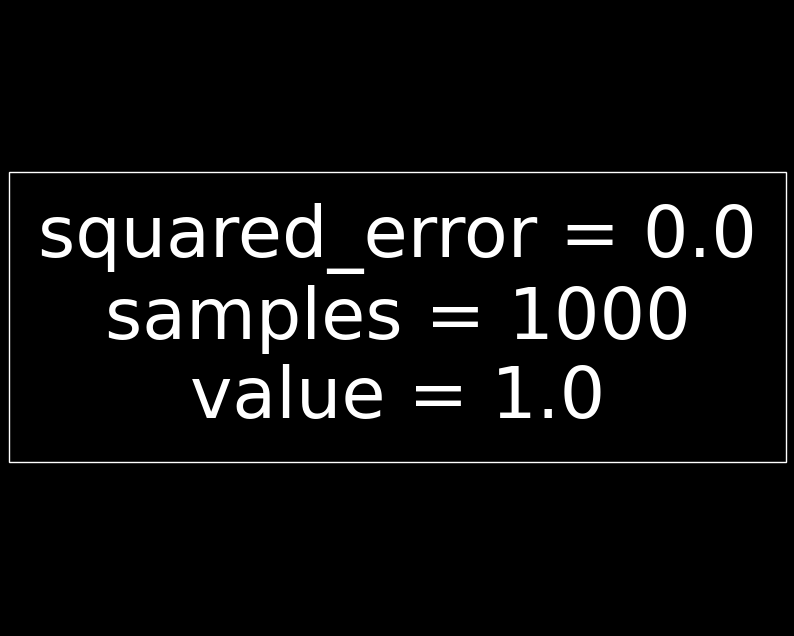

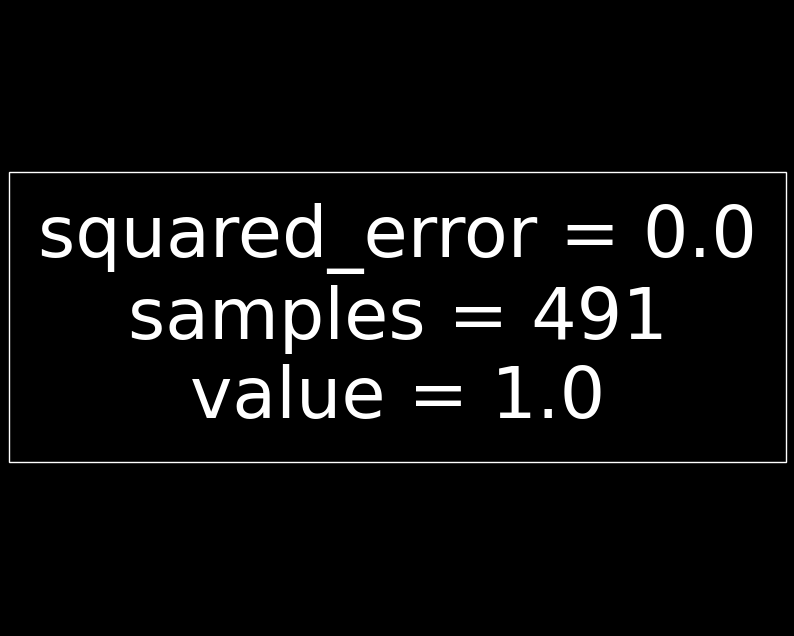

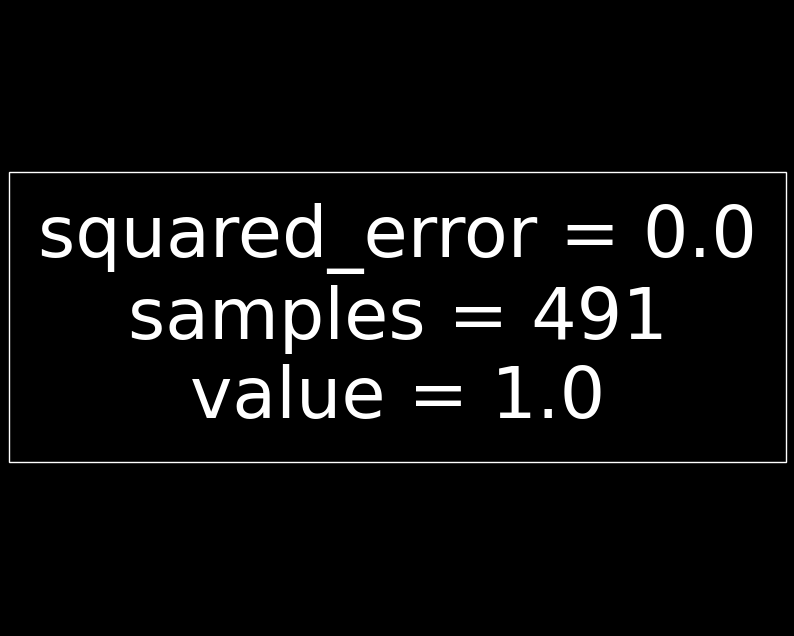

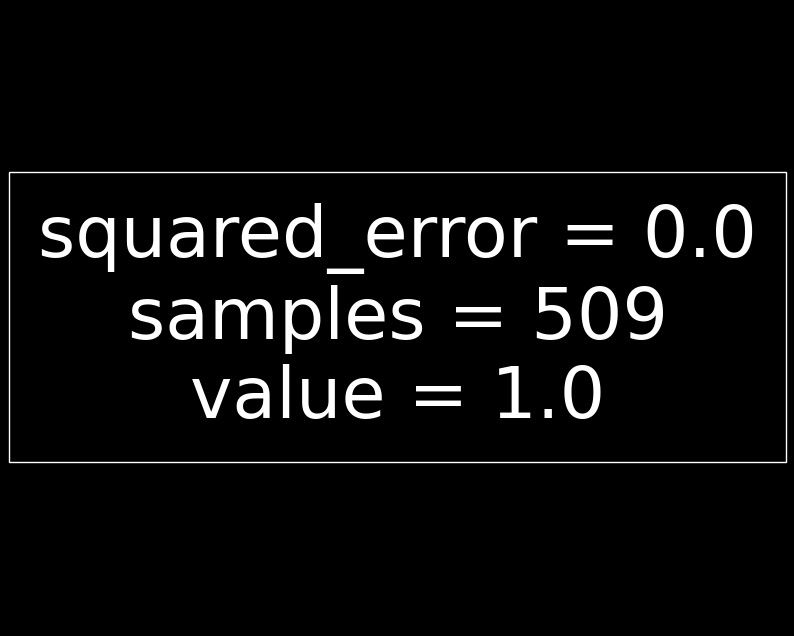

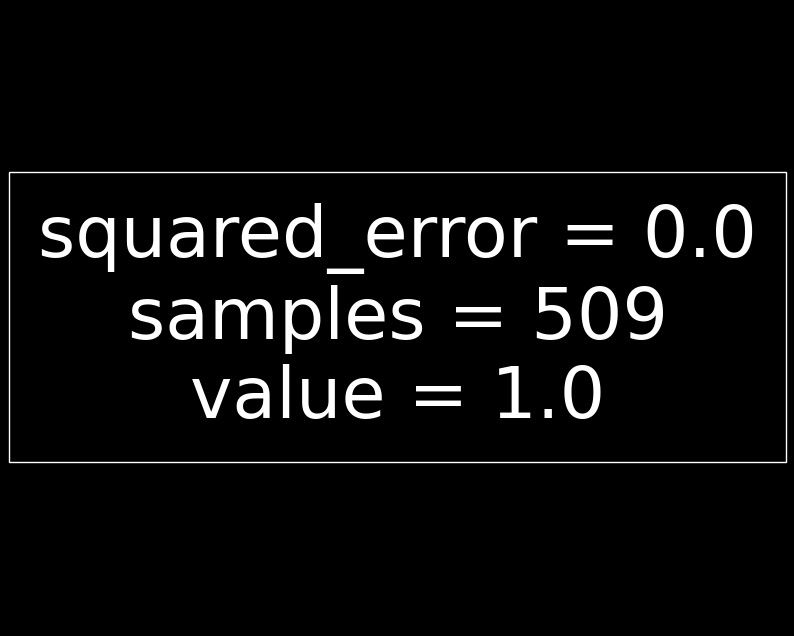

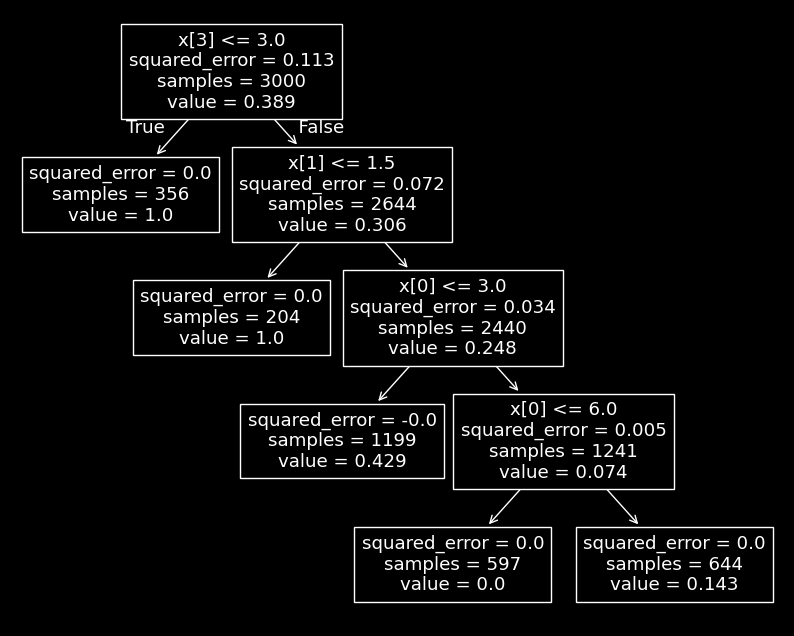

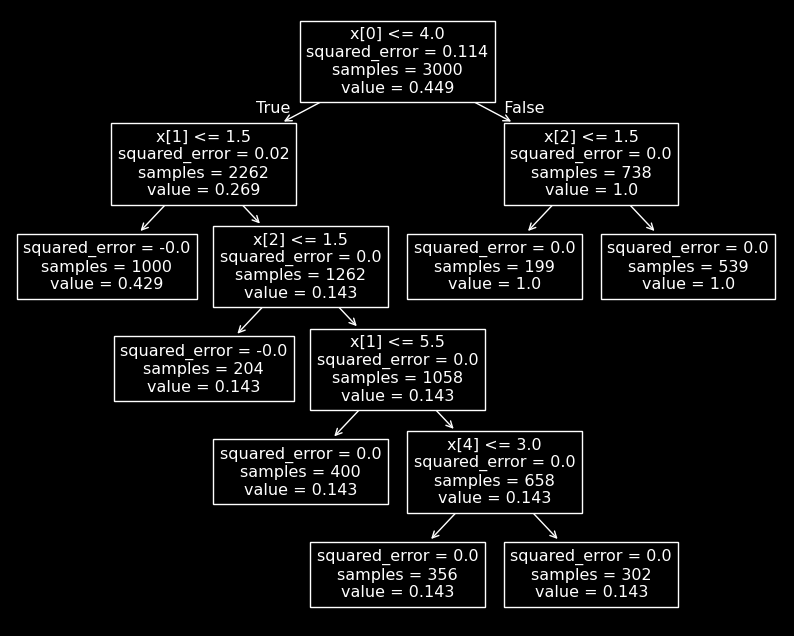

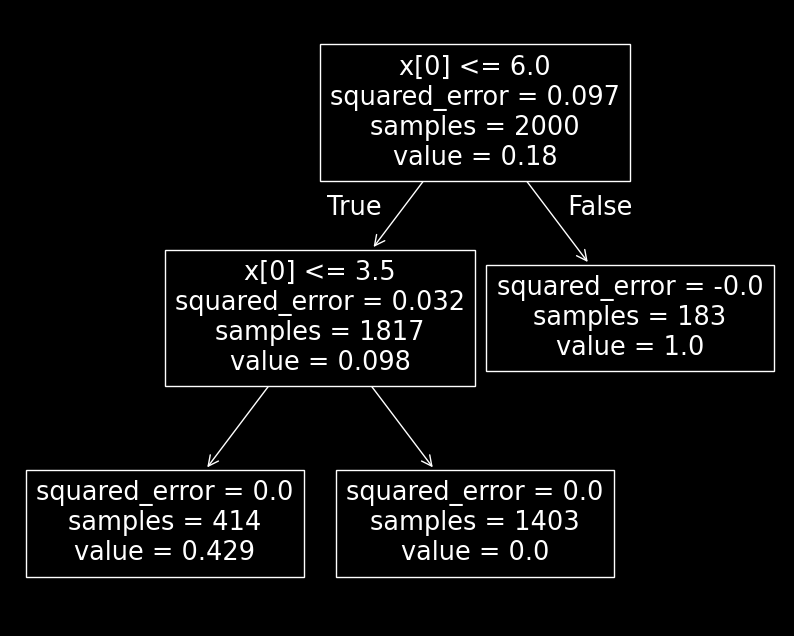

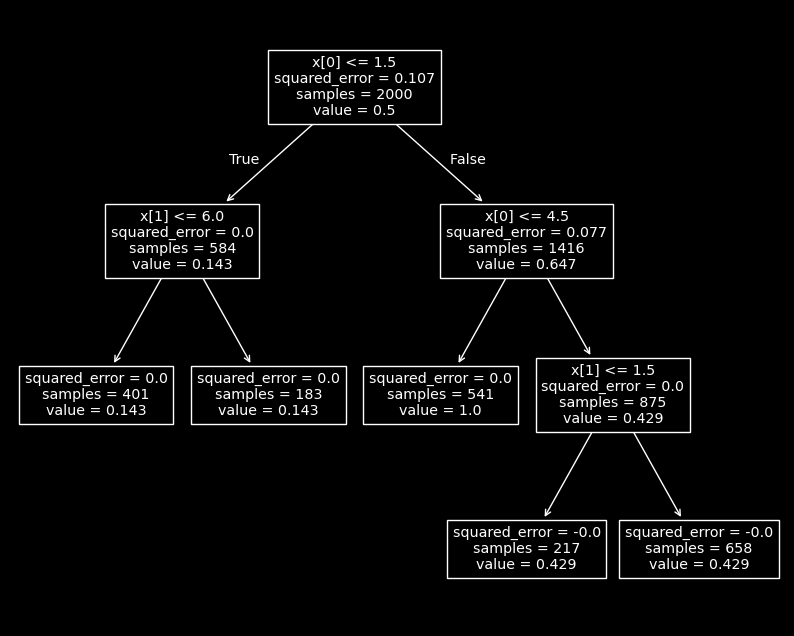

In [15]:
for clf,_ in classifier_dict_tasks.values():
    plt.figure(figsize=(10, 8))
    sktree.plot_tree(clf)
    plt.show()

In [16]:
# Creo il tensor con le colonne codificate in interi
data_complete = torch.tensor(encode_complete(df_traces_balanced.values), dtype=torch.long)
data_regions = torch.tensor(encode_regions(df_regions.values), dtype=torch.long)
data_tasks = torch.tensor(encode_tasks(df_tasks.values), dtype=torch.long)
data_times = torch.tensor(times, dtype=torch.long)

In [17]:
n = int(0.8 * len(df_traces_balanced)) # 80% train, 20% validation

# Valori per il modello completo - REGIONE + TASK
block_size_mc = 256
n_embd_mc = 256
dropout_mc = 0.30
n_head_mc = 8
n_layer_mc = 3
batch_size_mc = 16
eval_iters_mc = 200
eval_interval_mc = 150
max_iters_mc = 500
learning_rate_mc = 3e-4

# Creazione modello BPMNTransformer - Token --> REGIONE + TASK
model_complete = BPMNTransformer(vocab_size_complete, block_size_mc, n_embd_mc, dropout_mc, n_head_mc, n_layer_mc)
m_c = model_complete.to(device)

optimizer_m = torch.optim.AdamW(model_complete.parameters(), lr=learning_rate_mc) # Ottimizzatore pyTorch

train_data = data_complete[:n]
val_data = data_complete[n:]

max_iters_mc = 150
# Train del modello - codice preso dal video di karpathy (alleno il modello mc (modello completo - REGIONI + TASK) )
for iter in range(max_iters_mc):
    if iter % eval_interval_mc == 0 or iter == max_iters_mc - 1: # Ogni tot stampo la loss corrente
        losses = estimate_loss(model_complete, eval_iters_mc, train_data, val_data, batch_size_mc, block_size_mc, device)
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch_model('train', train_data, val_data, batch_size_mc, block_size_mc, device) # Pesco tracce

    logits, loss = model_complete(xb, yb) # Esegue il forward e predice
    optimizer_m.zero_grad(set_to_none=True) # Reset gradienti (puliamo i calcoli del giro precedente)

    loss.backward() #Errore per neurone
    optimizer_m.step() # Aggiorna automaticamente i pesi per sbagliare di meno al giro dopo

step 0: train loss 2.3865, val loss 2.3887
step 149: train loss 0.6976, val loss 0.7294


In [18]:
# Valori per il modello time
block_size_mt = 64
n_embd_mt = 128
dropout_mt = 0.30
n_head_mt = 8
n_layer_mt = 3
batch_size_mt = 16
eval_iters_mt = 200
eval_interval_mt = 150
max_iters_mt = 3000
learning_rate_mt = 3e-4

# Creazione modello TimeTransformer
time_model = TimeTransformer(vocab_size_complete, block_size_mt, n_embd_mt, dropout_mt, n_head_mt, n_layer_mt, separated_regions=False)
m_t = time_model.to(device)

optimizer_t = torch.optim.AdamW(time_model.parameters(), lr=learning_rate_mt) # Ottimizzatore pyTorch

train_times = data_times[:n]
val_times = data_times[n:]

max_iters_mt = 150
# Train del modello - codice preso dal video di karpathy (alleno il modello del Tempo - adattata)
for iter in range(max_iters_mt):
    if iter % eval_interval_mt == 0 or iter == max_iters_mt - 1: # Ogni tot stampo la loss corrente
        losses = estimate_loss_times(time_model, eval_iters_mt, train_data, train_times, val_data, val_times, batch_size_mt, block_size_mt, device)
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xd, xt, y = get_batch_model_time('train', train_data, train_times, val_data, val_times, batch_size_mt, block_size_mt, device) # Pesco tracce

    logits, loss = time_model(xd, xt, targets=y) # Esegue il forward e predice
    optimizer_t.zero_grad(set_to_none=True) # Reset gradienti (puliamo i calcoli del giro precedente)

    loss.backward() #Errore per neurone
    optimizer_t.step() # Aggiorna automaticamente i pesi per sbagliare di meno al giro dopo

step 0: train loss 0.4190, val loss 0.4257
step 149: train loss 0.0523, val loss 0.0627


In [20]:
# Valori per il modello completo - SOLO TASK
block_size_mtask = 256
n_embd_mtask = 256
dropout_mtask = 0.30
n_head_mtask = 8
n_layer_mtask = 3
batch_size_mtask = 16
eval_iters_mtask = 200
eval_interval_mtask = 150
max_iters_mtask = 500
learning_rate_mtask = 3e-4

# Creazione modello BPMNTransformer - Token --> SOLO TASK
model_task = BPMNTransformer(vocab_size_tasks, block_size_mtask, n_embd_mtask, dropout_mtask, n_head_mtask, n_layer_mtask)
m_task = model_task.to(device)

optimizer_mtask = torch.optim.AdamW(model_task.parameters(), lr=learning_rate_mtask) # Ottimizzatore pyTorch

train_data_task = data_tasks[:n]
val_data_task = data_tasks[n:]

max_iters_mtask = 150
# Train del modello - codice preso dal video di karpathy (alleno il modello mc (modello completo - REGIONI + TASK) )
for iter in range(max_iters_mtask):
    if iter % eval_interval_mtask == 0 or iter == max_iters_mtask - 1: # Ogni tot stampo la loss corrente
        losses = estimate_loss(model_task, eval_iters_mtask, train_data_task, val_data_task, batch_size_mtask, block_size_mtask, device)
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch_model('train', train_data_task, val_data_task, batch_size_mtask, block_size_mtask, device) # Pesco tracce

    logits, loss = model_task(xb, yb) # Esegue il forward e predice
    optimizer_mtask.zero_grad(set_to_none=True) # Reset gradienti (puliamo i calcoli del giro precedente)

    loss.backward() #Errore per neurone
    optimizer_mtask.step() # Aggiorna automaticamente i pesi per sbagliare di meno al giro dopo

step 0: train loss 1.8100, val loss 1.8101
step 149: train loss 0.7420, val loss 0.7547


In [21]:
# Valori per il modello completo - SOLO TASK
block_size_mregion = 256
n_embd_mregion = 256
dropout_mregion = 0.30
n_head_mregion = 8
n_layer_mregion = 3
batch_size_mregion = 16
eval_iters_mregion = 200
eval_interval_mregion = 150
max_iters_mregion = 500
learning_rate_mregion = 3e-4

# Creazione modello BPMNTransformer - Token --> SOLO TASK
model_region = RegionTransformer(vocab_size_regions, vocab_size_tasks, block_size_mregion, n_embd_mregion, dropout_mregion, n_head_mregion, n_layer_mregion)
m_region = model_region.to(device)

optimizer_mregion = torch.optim.AdamW(model_region.parameters(), lr=learning_rate_mregion) # Ottimizzatore pyTorch

train_data_region = data_regions[:n]
val_data_region = data_regions[n:]

max_iters_mregion = 150
# Train del modello - codice preso dal video di karpathy (alleno il modello mc (modello completo - REGIONI + TASK) )
for iter in range(max_iters_mregion):
    if iter % eval_interval_mregion == 0 or iter == max_iters_mregion - 1: # Ogni tot stampo la loss corrente
        losses = estimate_loss_region(model_region, eval_iters_mregion, train_data_task, train_data_region, val_data_task, val_data_region, batch_size_mregion, block_size_mregion, device)
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    x_task, x_region, y = get_batch_model_region('train', train_data_task, val_data_task, train_data_region, val_data_region, batch_size_mregion, block_size_mregion, device) # Pesco tracce

    logits, loss = model_region(x_region, x_task, y) # Esegue il forward e predice
    optimizer_mregion.zero_grad(set_to_none=True) # Reset gradienti (puliamo i calcoli del giro precedente)

    loss.backward() #Errore per neurone
    optimizer_mregion.step() # Aggiorna automaticamente i pesi per sbagliare di meno al giro dopo

step 0: train loss 1.9260, val loss 1.9320
step 149: train loss 0.1767, val loss 0.1865


In [22]:
# Valori per il modello time v2
block_size_mt_v2 = 64
n_embd_mt_v2 = 128
dropout_mt_v2 = 0.30
n_head_mt_v2 = 8
n_layer_mt_v2 = 3
batch_size_mt_v2 = 16
eval_iters_mt_v2 = 200
eval_interval_mt_v2 = 150
max_iters_mt_v2 = 3000
learning_rate_mt_v2 = 3e-4

# Creazione modello TimeTransformerV2
time_model_v2 = TimeTransformer(vocab_size_tasks, block_size_mt_v2, n_embd_mt_v2, dropout_mt_v2, n_head_mt_v2, n_layer_mt_v2, vocab_size_regions, separated_regions=True)
m_t_v2 = time_model_v2.to(device)

optimizer_t_v2 = torch.optim.AdamW(time_model_v2.parameters(), lr=learning_rate_mt_v2) # Ottimizzatore pyTorch

train_times = data_times[:n]
val_times = data_times[n:]

max_iters_mt_v2 = 150
# Train del modello - codice preso dal video di karpathy (alleno il modello del Tempo - adattata per la versione V2 del TimeTransformer (task e regioni separate))
for iter in range(max_iters_mt_v2):
    if iter % eval_interval_mt_v2 == 0 or iter == max_iters_mt_v2 - 1: # Ogni tot stampo la loss corrente
        losses = estimate_loss_times_v2(time_model_v2, eval_iters_mt_v2, train_data_task, train_data_region, train_times, val_data_task, val_data_region, val_times, batch_size_mt_v2, block_size_mt_v2, device)
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xta, xr, xt, y = get_batch_model_time_v2('train', train_data_task, train_data_region, train_times, val_data_task, val_data_region, val_times, batch_size_mt_v2, block_size_mt_v2, device) # Pesco tracce

    logits, loss = time_model_v2(xta, xt, xr, y) # Esegue il forward e predice
    optimizer_t_v2.zero_grad(set_to_none=True) # Reset gradienti (puliamo i calcoli del giro precedente)

    loss.backward() #Errore per neurone
    optimizer_t_v2.step() # Aggiorna automaticamente i pesi per sbagliare di meno al giro dopo

step 0: train loss 0.4808, val loss 0.4858
step 149: train loss 0.0604, val loss 0.0719


In [ ]:
# Generazione - REGIONE+TASK --> Time

context = torch.tensor(encode_complete([[0]*(num_regions+num_tasks)]), dtype=torch.long, device=device).unsqueeze(0)
context_time = torch.tensor([0], dtype=torch.float32, device=device).unsqueeze(0) # Lo zero sembra corretto al momento (da verificare, sembrerebbe andare bene anche 1)

# Faccio indovinare il primo time (per (0,0,0,...,0) --> cosi prende meglio il contesto, altrimenti inizia a cannare i primi valori)
first_time_guess = m_t.predict_next_time(idx_tasks=context, idx_times=context_time, block_size=block_size_mt)
#first_time_guess = torch.round(first_time_guess)
context_time = torch.cat((context_time, first_time_guess), dim=1)

max_new_tokens = 30
generated_indices_completegen = []
generated_times_completegen = []

for step in range(max_new_tokens):
    next_id = m_c.predict_next_task(idx=context, block_size=block_size_mc)
    context = torch.cat((context, next_id), dim=1)
    next_time = m_t.predict_next_time(idx_tasks=context, idx_times=context_time, block_size=block_size_mt)
    #next_time = torch.round(next_time)
    context_time = torch.cat((context_time, next_time), dim=1)
    generated_indices_completegen.append(next_id.item())
    generated_times_completegen.append(next_time.item())

decoded_output_complete_firstgen = decode_complete(generated_indices_completegen)

for i in range(len(decoded_output_complete_firstgen)):
    step = decoded_output_complete_firstgen[i]
    bit_list = [int(b) for b in step]

    time = generated_times_completegen[i]

    '''if i>0:
        real_time = time_intra_token[tuple(decoded_output_complete_firstgen[i-1]),tuple(decoded_output_complete_firstgen[i])]
    else:
        real_time = time_intra_token[tuple([0]*(num_regions+num_tasks)),tuple(decoded_output_complete_firstgen[i])]
    print(f"{bit_list} - {time} - {real_time}")'''
    print(f"{bit_list} - {round(time,4)}")

In [ ]:
# Generazione - TASK --> REGIONE --> Time
context_task = torch.tensor(encode_tasks([[0]*num_tasks]), dtype=torch.long, device=device).unsqueeze(0)
context_region = torch.tensor(encode_regions([[0]*num_regions]), dtype=torch.long, device=device).unsqueeze(0)
context_time = torch.tensor([0], dtype=torch.float32, device=device).unsqueeze(0) # Lo zero sembra corretto al momento (da verificare, sembrerebbe andare bene anche 1)

max_new_tokens = 30
generated_indices_task = []
generated_indices_region = []
generated_times_partgen = []

for step in range(max_new_tokens):
    next_task = m_task.predict_next_task(idx=context_task, block_size=block_size_mtask)
    context_task = torch.cat((context_task, next_task), dim=1)

    context_task_aligned = context_task[:, 1:]

    next_region = m_region.predict_next_region(idx_region=context_region, idx_task=context_task_aligned, block_size=block_size_mregion)
    context_region = torch.cat((context_region, next_region), dim=1)

    context_region_aligned = context_region[:, 1:]

    next_time = m_t_v2.predict_next_time(idx_tasks=context_task_aligned, idx_regions=context_region_aligned, idx_times=context_time, block_size=block_size_mt_v2)
    #next_time = torch.round(next_time)
    context_time = torch.cat((context_time, next_time), dim=1)

    generated_indices_task.append(next_task.item())
    generated_indices_region.append(next_region.item())
    generated_times_partgen.append(next_time.item())

decoded_output_complete_secondgen = []

for i in range(max_new_tokens):
    t_int = generated_indices_task[i]
    r_int = generated_indices_region[i]

    t_bits = [int(b) for b in decode_tasks([t_int])[0]]
    r_bits = [int(b) for b in decode_regions([r_int])[0]]

    bit_list = r_bits + t_bits

    time = generated_times_partgen[i]

    if i > 0:
        past_t_bits = [int(b) for b in decode_tasks([generated_indices_task[i-1]])[0]]
        past_r_bits = [int(b) for b in decode_regions([generated_indices_region[i-1]])[0]]
        past_bit_list = past_r_bits + past_t_bits

        key = (tuple(past_bit_list), tuple(bit_list))
    else:
        key = (tuple([0]*(num_regions+num_tasks)), tuple(bit_list))

    decoded_output_complete_secondgen.append(tuple(bit_list))

    '''if key in time_intra_token:
        real_time = time_intra_token[key]
    else:
        real_time = None

    print(f"{bit_list} - {time} - {real_time}")'''
    print(f"{bit_list} - {round(time,4)}")


In [ ]:
print("\n--- TRACCE GENERATE ---")

decoded_output = decoded_output_complete_firstgen  #decoded_output_complete_firstgen

traces_generated = []
current_trace_generated = []
for i, step in enumerate(decoded_output):
    bit_list = [int(b) for b in step]
    current_trace_generated.append(bit_list)
    if bit_list == [0]*(num_regions+num_tasks):
        traces_generated.append(current_trace_generated)
        current_trace_generated = []
    #print(f"Step {i:02d}: {bit_list}")

traces_generated.remove(traces_generated[0]) #Rimuovo la prima che è sempre [], generata ed inserita dall'algoritmo sopra
for i,trace in enumerate(traces_generated):
    print(f"{i}: {trace}")


In [ ]:
from pm4py.algo.conformance.alignments.petri_net import algorithm as alignments
from pm4py.objects.log.obj import Trace, Event, EventLog

# Facciamo il decoding delle tracce generate
#print(traces_generated)
traces_decoded = get_decoding(traces_generated, net.regions, net.tasks)
for i,trace in enumerate(traces_decoded):
    print(f"{i}: {trace}")

# Creiamo il l'EventLog di ogni traccia per poi poterla allineare
eventlog_traces = EventLog()
for trace in traces_decoded:
    t = Trace()
    for activity in trace:
        t.append(Event({'concept:name': activity}))
    eventlog_traces.append(t)


check = ["P", "X", "L"]
start = tuple(["start_" + c for c in check])
end = tuple(["end_" + c for c in check if c!="L"]) # si escludono gli end loop
loop = tuple(["back_L"]) + tuple(["end_L"])

silent_transition_prefixes = start + end + loop

model_cost_function = dict()
sync_cost_function = dict()

# METTIAMO 10000 come di default???
for t in net.net.transitions: # Prendo tutte le transizioni
    if t.label is not None and t.label.startswith(silent_transition_prefixes): # Se è una transizione silente,
        model_cost_function[t] = 0
        sync_cost_function[t] = 10000

    elif t.label is None:
        model_cost_function[t] = 0
        sync_cost_function[t] = 10000

    else: # Se è un task vero e proprio
        model_cost_function[t] = 10000
        sync_cost_function[t] = 0

parameters = {
    alignments.Parameters.PARAM_MODEL_COST_FUNCTION: model_cost_function,
    alignments.Parameters.PARAM_SYNC_COST_FUNCTION: sync_cost_function
}

# Eseguiamo l'allineamento
aligned_traces = alignments.apply(eventlog_traces, net.net, net.initial_marking, net.final_marking, parameters=parameters)
for i,trace in enumerate(aligned_traces):
    print(f"{i}: {trace}")

In [ ]:
check = ["P", "X", "L"]
start = tuple(["start_" + c for c in check])
end = tuple(["end_" + c for c in check if c!="L"]) # si escludono gli end loop
back_loop = tuple(["back_L"])

# Puliamo l'allineamento e otteniamo la traccia allineata più vicina a quella generata
aligned_traces_cleaned = []
for a_trace in aligned_traces:
    trace_cleaned = []
    trace = a_trace['alignment']

    print(trace)

    for _, net_step in trace: #trans --> trans step , net --> real petri net step
        if net_step is not None:
            if not (net_step.startswith(start) or net_step.startswith(end) or net_step.startswith(back_loop)) and not net_step=='>>':
                trace_cleaned.append(net_step)

    aligned_traces_cleaned.append(trace_cleaned)


for i,trace in enumerate(aligned_traces_cleaned):
    print(f"{i}: {trace}")

# Codifichiamo le tracce allineati (per poi poterle confrontare con quelle generate dal transformer)
aligned_traceEncoded_regions, aligned_traceEncoded_tasks = get_encoding(aligned_traces_cleaned, net.regions, net.tasks, net.open_clauses, net.end_clauses)
df_aligned_traces = pd.concat([aligned_traceEncoded_regions, aligned_traceEncoded_tasks], axis=0)
print(df_aligned_traces)


In [86]:
# Creo una lista delle tracce codificate (ogni traccia è una lista dove ogni elemento è una colonna del df, ossia uno step) --> più facili da confrontare quando calcoliamo la distanza
aligned_traces_encoded = []
aligned_trace_encoded = []
for element in df_aligned_traces.T.values:
    element = element.tolist()
    aligned_trace_encoded.append(element)
    if element == [0] * (num_regions+num_tasks):
        aligned_traces_encoded.append(aligned_trace_encoded)
        aligned_trace_encoded = []

# Andiamo a calcolare il costo con la edit distance (weighted_levenshtein)
for i in range(len(aligned_traces_encoded)):
    generated_t = traces_generated[i]
    aligned_t = aligned_traces_encoded[i]

    gen_tuples = [tuple(step) for step in generated_t]
    aligned_tuples = [tuple(step) for step in aligned_t]

    total_possible_column = set(gen_tuples + aligned_tuples) # Prendo tutte le possibili colonne per andare a creare il dizionario delle sostituzioni

    # Se volessi dizionario delle distanze bisognerebbe usare questo pezzo di codice (adesso usiamo distanza di hamming di base nel codice)
    '''cost_sub = {}
    for e1 in total_possible_column:
        for e2 in total_possible_column:
            if e1 != e2:
                counter = 0
                for i in range(len(e1)):
                    if e1[i] != e2[i]:
                        counter+=1
                cost_sub[(e1,e2)] = counter'''

    cost = edit_distance_weighted_levenshtein(generated_t, aligned_t, num_regions+num_tasks, num_regions+num_tasks, hamming_distance) # Utilizziamo la distanza di hamming al momento
    print(cost)

#costo = edit_distance_weighted_levenshtein(traccia_ai, traccia_pulita, cost_ins, cost_del, cost_sub)
#print(f"Costo di correzione totale: {costo}")

1.0
0.0
22.0
22.0
